## **Libraries For The Project**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### **Load Dataset**

In [2]:
df = pd.read_csv('insurance.csv')

## **EDA Start**

In [3]:
# lets check the shape and start the other process of eda
df.shape
# this tells us we have 1338 and 7 columns

(1338, 7)

In [4]:
# lets check null values now
df.isna().sum()
# no null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [5]:
df.duplicated().sum()


np.int64(1)

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


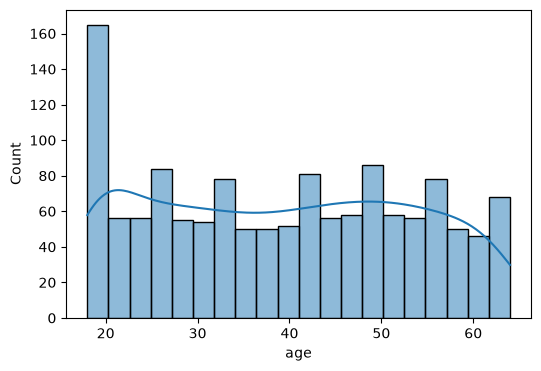

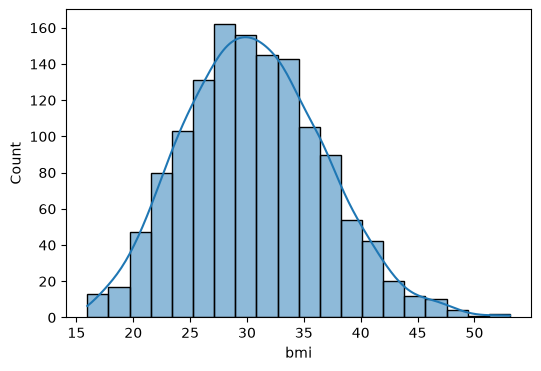

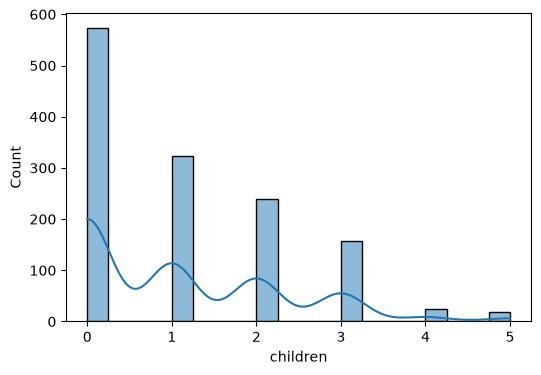

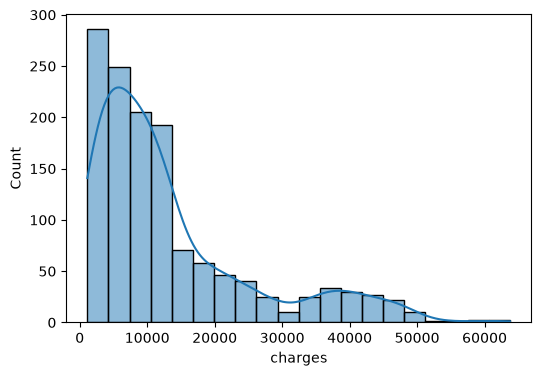

In [8]:
# now lets visualize data for numeric columns
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

In [9]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

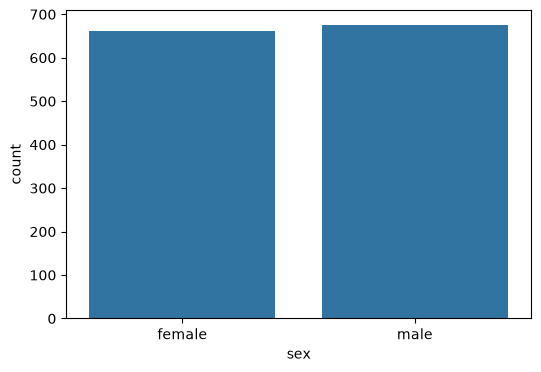

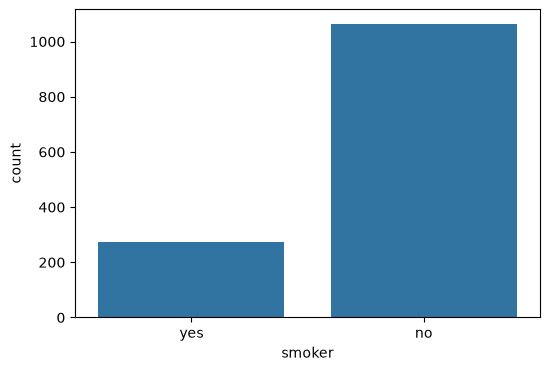

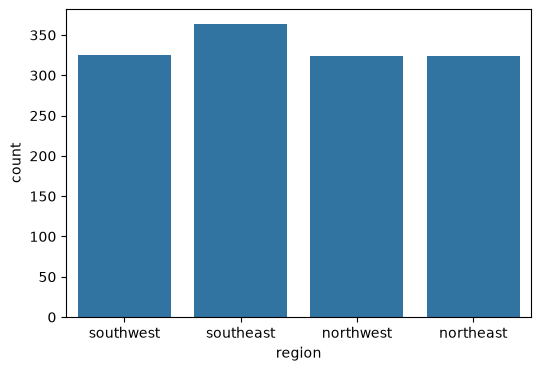

In [10]:
non_numeric_cols = ['sex','smoker','region']
for cols in non_numeric_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df,x=cols)

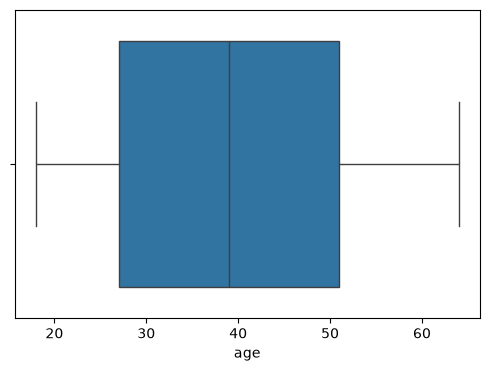

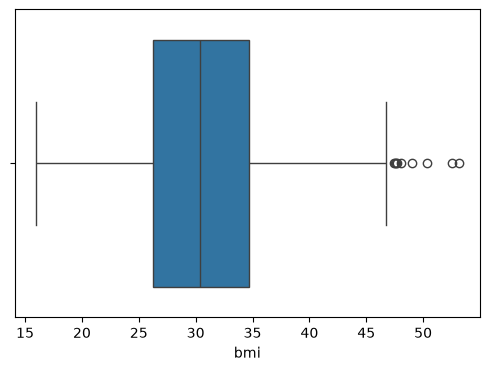

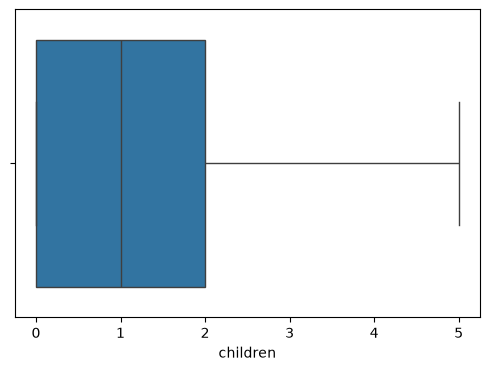

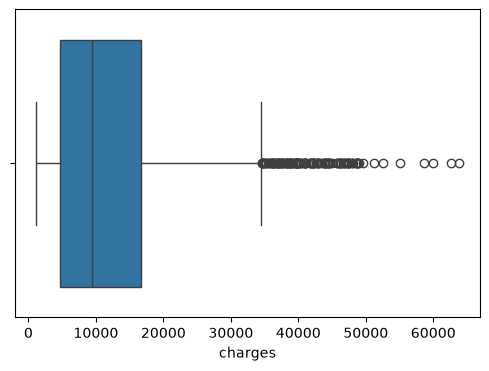

In [11]:
# creating a boxplot to visualize outliers of numeric columns
for cols in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[cols])

### **These are all the steps of EDA**

<Axes: >

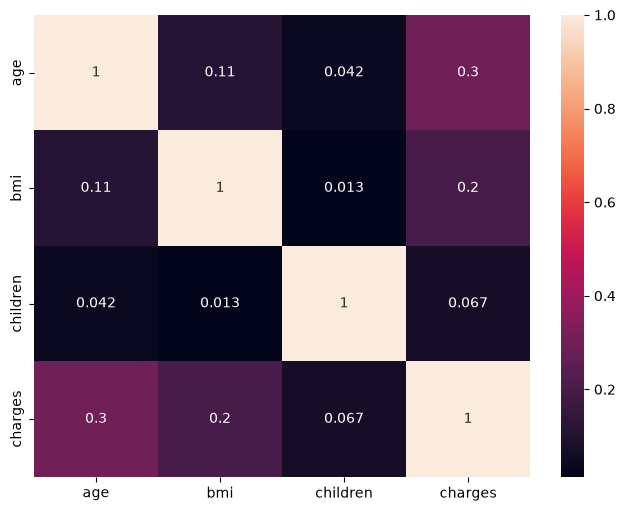

In [12]:
# now lets check relationship between each
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [13]:
# we can see how each column is correlated with each other for example childrens and ages are not highly correlated u can see clearly in the correlation. For example we can see how less children is co related with other columns we can somehow assume that we can drop children column just saying we will properly see while we will be training our model for now we are keeping this as our assumptions

## **Data Cleaning**
    The data already was cleaned so its not neccessary for this dataset

In [14]:
df_cleaned = df.copy()
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

    Now we will be converting our data that has string and object datatype into clean numeric for proper training of our machine learning model

In [16]:
# lets do label encoding for our sex columns
df_cleaned['sex'] = df_cleaned['sex'].map({
    "male" : 0,
    "female" : 1
})

In [17]:
# now for smoker
df_cleaned['smoker'] = df_cleaned['smoker'].map({
    "yes" : 1,
    "no" : 0
})

In [18]:
df_cleaned.rename(columns={
    "sex" : "is_female",
    "smoker" : "is_smoker"
    },inplace=True)

In [19]:
df_cleaned.head()
# now only region remains

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [20]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['region'],drop_first=True)

In [21]:
df_cleaned = df_cleaned.astype(int)

In [22]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


## **Feature Engineering And Extraction**

<Axes: xlabel='bmi', ylabel='Count'>

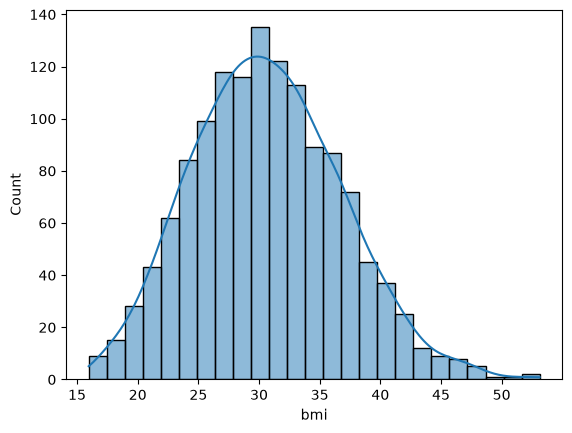

In [23]:
sns.histplot(df['bmi'],kde=True)

In [24]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins = [0,18.5,24.9,29.9,float('inf')],
    labels=['Underweight','Normal','Overweight','Obesity']
)

In [25]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obesity
2,28,0,33,3,0,4449,0,1,0,Obesity
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight


In [26]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [27]:
df_cleaned=df_cleaned.astype(int)

In [28]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obesity
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


**We did feature engineering of bmi table for better understanding of data**

In [29]:
from sklearn.preprocessing import StandardScaler
cols = ['age','bmi','children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [30]:
df_cleaned
# dont worry every data was perfect its just scaled now so that our ml model can understand it properly

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obesity
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


In [31]:
from scipy.stats import pearsonr

# ---------------------------------------------
# Pearson Correlation Calculation
# ---------------------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obesity'
]
correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

In [32]:
correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['feature', 'pearson_correlation']
).sort_values(by='pearson_correlation', ascending=False).reset_index(drop=True)

In [33]:
correlation_df
# it stays in between 0 and 1

,feature,pearson_correlation
0,is_smoker,0.787234
1,age,0.298309
2,bmi_category_Obesity,0.200348
3,bmi,0.196236
4,region_southeast,0.073577
5,children,0.067390
6,region_northwest,-0.038695
7,region_southwest,-0.043637
8,is_female,-0.058046
9,bmi_category_Normal,-0.104042


we will see what columns are highly correlated for our output variable then we will act accordingly

![image.png](attachment:image.png)

In [34]:
# in categorical columns we can check correlations but its not ideal so we will be using chi square test
categorical_features = [
    'is_female','is_smoker',
    'region_northwest','region_southeast','region_southwest','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obesity'
    ]

In [35]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'],q=4,labels=False)

In [36]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obesity', 'charges_bin'],
      dtype='str')

In [37]:
chi2_result = {}
for col in categorical_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_result[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

In [38]:
chi2_df = pd.DataFrame(chi2_result).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_Obesity,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_Overweight,4.25149,0.235557,Accept Null (Drop Feature)
bmi_category_Normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [39]:
final_df = df_cleaned[['age','bmi','children','is_smoker','charges','region_southeast','bmi_category_Obesity']]

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X = final_df.drop('charges',axis=1)
y = final_df['charges']
# dropping charges because we will be predicted x will be the input variables and y will be our output variable i hope u got my point

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

**X_train**:
    It is the data that we will we using for training of our data it will include all the features except the output variable.

**Y_train**:
    It is the data that we will we using for training of our data it will include the output variable.

**X_test**:
    It will be the data that we will be predicting

**Y_test**:
    It will be the data that we will be comparing our predicted values to determine the accuracy and things.


In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
model = LinearRegression()

In [45]:
model.fit(X_train,y_train)
# model created it was that easy :)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 3490.29, 563.28, 645.83,23072.57, -262.45, 3287.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','bmi','children','is_smoker','region_southeast', 'bmi_category_Obesity']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6804
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,6


In [46]:
y_pred = model.predict(X_test)

In [47]:
y_pred

array([ 7895.98171903,  5343.47027643, 14576.59740409, 32492.83968242,
        8990.08006709, 13373.06276439, 30152.11781515,  1367.52794653,
       11161.40351438, 10055.93622486, 10787.2900016 , 32174.59308227,
       31577.60405507, 16191.33457964, 10246.97631717,  8525.58287359,
        5521.6838043 , 32493.68811847,  3341.74449234,  3841.47459949,
        4723.3334226 , 28824.73893133, 13833.26549896, 29570.5761387 ,
       31474.39380991,  6306.1999482 , 34981.46900923, 37910.8070355 ,
       12455.3218348 , 14274.62339125,  7536.43539605, 13085.7714254 ,
         554.49489098, 11378.21221962, 37537.29418422, 13320.70882737,
        3669.37163405,  4503.93565595, 31516.47501607,  7975.84489434,
        6035.24814925, 30364.60511465, 35305.78241856, 13136.62773354,
        7945.83035381,  2951.24290819,  5132.83908634,  7584.49487414,
        3487.14664963, 10426.73600525,  7784.04012514, 10537.78063176,
       30288.90410778,  4723.3334226 , 11711.14149362, 11485.71692371,
      

In [48]:
y_test

900      8688
1064     5708
1256    11436
298     38746
237      4463
        ...  
534     13831
542     13887
760      3925
1284    47403
1285     8534
Name: charges, Length: 268, dtype: int64

In [49]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test,y_pred)

In [ ]:
# r2
# lets calculated adjusted r2
n = X_test.shape[0] #no.of rows
p = X_test.shape[1] #no.of columns
adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.7994599155203782